<a href="https://colab.research.google.com/github/miguelin-2006/Ejercicios-de-Python/blob/main/API_cambio_de_moneda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo I+D+I: Análisis de Tipos de Cambio con API de Frankfurter
## Paso 1: Descarga de datos desde la API y creación del CSV
Obtenemos las tasas de cambio actualizadas con base EUR y guardamos los resultados en un archivo CSV.

In [5]:
import pandas as pd
import requests

# 1. Obtener datos de la API de Frankfurter
url = "https://api.frankfurter.dev/v1/latest?from=EUR"
response = requests.get(url)
data = response.json()

# 2. Extraer fecha, base y tipos de cambio
fecha = data['date']
base = data['base']
rates = data['rates']

# 3. Recorrer los datos de las monedas principales
monedas_interes = ['USD', 'GBP', 'CAD', 'JPY', 'CHF']
registros = []

for moneda in monedas_interes:
    if moneda in rates:
        registros.append({
            'Fecha': fecha,
            'Moneda_Base': base,
            'Moneda_Destino': moneda,
            'Tipo_de_Cambio': rates[moneda]
        })

# 4. Crear el DataFrame y guardarlo en un archivo CSV local y en Google Drive
df_api = pd.DataFrame(registros)

# Guardar en local de Colab
df_api.to_csv('cambio_moneda_eur.csv', index=False)

# Guardar en Google Drive
df_api.to_csv('/content/drive/MyDrive/cambio_moneda_eur.csv', index=False)

print("✅ Datos descargados de la API y archivo CSV guardado con éxito.")
display(df_api)

✅ Datos descargados de la API y archivo CSV guardado con éxito.


,Fecha,Moneda_Base,Moneda_Destino,Tipo_de_Cambio
0,2026-10-02,EUR,USD,1.12250
1,2026-10-02,EUR,GBP,0.85033
2,2026-10-02,EUR,CAD,1.59840
3,2026-10-02,EUR,JPY,176.99000
4,2026-10-02,EUR,CHF,0.92790


## Paso 2: Lectura del CSV y análisis estadístico
Leemos el archivo CSV generado anteriormente y calculamos métricas como mínimos, máximos y desviaciones.

In [6]:
# 1. Leer el archivo CSV previamente guardado
df = pd.read_csv('cambio_moneda_eur.csv')

# 2. Obtener estadísticos generales del DataFrame
print("--- RESUMEN ESTADÍSTICO COMPLETO ---")
display(df.describe())

# 3. Calcular mínimos, máximos y medias específicos
print("\n--- ESTADÍSTICOS ESPECÍFICOS DEL TIPO DE CAMBIO ---")
print(f"Tipo de cambio Máximo: {df['Tipo_de_Cambio'].max()}")
print(f"Tipo de cambio Mínimo: {df['Tipo_de_Cambio'].min()}")
print(f"Tipo de cambio Promedio: {df['Tipo_de_Cambio'].mean():.4f}")

--- RESUMEN ESTADÍSTICO COMPLETO ---


,Tipo_de_Cambio
count,5.000000
mean,36.297826
std,78.649854
min,0.850330
25%,0.927900
50%,1.122500
75%,1.598400
max,176.990000



--- ESTADÍSTICOS ESPECÍFICOS DEL TIPO DE CAMBIO ---
Tipo de cambio Máximo: 176.99
Tipo de cambio Mínimo: 0.85033
Tipo de cambio Promedio: 36.2978


## Paso 3: Visualización de datos
Generamos un diagrama de barras para comparar de forma visual los tipos de cambio de las distintas divisas.

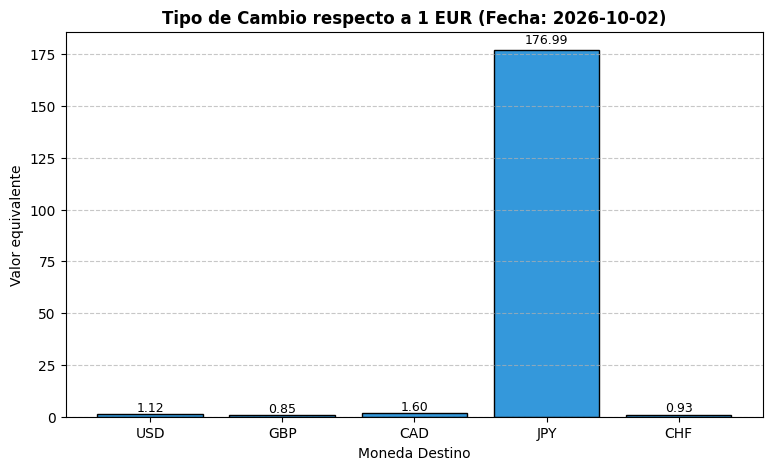

In [7]:
import matplotlib.pyplot as plt

# Crear diagrama de barras con los datos del CSV
plt.figure(figsize=(9, 5))
plt.bar(df['Moneda_Destino'], df['Tipo_de_Cambio'], color='#3498db', edgecolor='black')

# Títulos y etiquetas del gráfico
plt.title(f'Tipo de Cambio respecto a 1 {df["Moneda_Base"].iloc[0]} (Fecha: {df["Fecha"].iloc[0]})', fontsize=12, fontweight='bold')
plt.xlabel('Moneda Destino', fontsize=10)
plt.ylabel('Valor equivalente', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Etiquetar el valor sobre cada barra
for i, valor in enumerate(df['Tipo_de_Cambio']):
    plt.text(i, valor + (valor * 0.01), f"{valor:.2f}", ha='center', va='bottom', fontsize=9)

plt.show()